# From Prediction to Treatment Effects

Alex Ronczewski  
2026-06-18

## Outline

### Prerequisites

-   Notebook 3 of this stream: trees and forests, the
    train/test/cross-validate recipe, prediction is not causality.
-   The COMET Intermediate notebooks on regression, and some exposure to
    instrumental variables and difference-in-differences (ECON 326)
-   Comfort with `pandas` and basic Python at the COMET-intermediate
    level

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Explain the difference between a **prediction** problem and an
    **identification** problem.
2.  Write down the **potential outcomes** $Y(0)$ and $Y(1)$ and state
    the fundamental problem of causal inference.
3.  Define the **average treatment effect (ATE)** and the naive
    difference in means.
4.  Explain **selection bias**: why the naive comparison is not the ATE.
5.  State the **unconfoundedness** and **overlap** assumptions and
    explain how they identify the ATE by adjusting for $X$.
6.  Describe how the prediction tools from Notebooks 1 to 3 connect to
    causal estimation as **nuisance** estimators.
7.  Explain why using machine learning naively gives a **biased**
    treatment effect, and describe **orthogonalization** and
    **cross-fitting** as the fix.
8.  Say what to do when unconfoundedness fails, and connect it to **IV**
    and **DiD** from COMET.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV

RANDOM_STATE = 42  # fix randomness so the simulations are reproducible
TRUE_EFFECT = 1.0  # in our simulated worlds we get to set the real effect ourselves

## 1. Prediction to Causality

For two of our three notebooks we asked how well we can predict savings
from a household’s characteristics, with having a 401(k) as the main
variable. KNN, ridge, lasso, trees, and forests are all answers to that,
and each notebook closed with the same warning, that a model that
predicts savings well doesn’t tell us the **effect** of 401(k)
eligibility on savings.

From now on we’ll be shifting away from prediction. Prediction asks for
a good guess of $Y$, while causal analysis asks for the effect of a
**treatment** $D$ on $Y$: how much would a household’s savings change if
we made it eligible for a 401(k) and changed nothing else? Call $D$ the
treatment (here `e401`, eligibility), $Y$ the outcome (here `net_tfa`),
and $X$ the household’s other characteristics. We want the effect of $D$
on $Y$. This is causal analysis.

This notebook is more conceptual and dense than the other notebooks, but
it is also the most important.

### 1.1 Why a naive comparison fails

The obvious thing to do is compare the savings of households that are
eligible for a 401(k) with those that are not. We just subtract mean net
financial assets of ineligible households from eligible ones.

In [2]:
savings = pd.read_csv("datasets/Pension401k.csv")
confounders = ["age", "inc", "educ", "fsize", "marr", "twoearn", "db", "pira", "hown"]
D = savings["e401"].to_numpy()
Y = savings["net_tfa"].to_numpy()

naive_gap = Y[D == 1].mean() - Y[D == 0].mean()
print(f"Eligible households, mean net financial assets  : {Y[D == 1].mean():.1f}")
print(f"Ineligible households, mean net financial assets: {Y[D == 0].mean():.1f}")
print(f"Naive difference (eligible minus ineligible)    : {naive_gap:.1f}")

Eligible households, mean net financial assets  : 30.3
Ineligible households, mean net financial assets: 10.8
Naive difference (eligible minus ineligible)    : 19.6

Eligible households have about \$19,600 more in net financial assets. It
is tempting to call that the effect of eligibility for the 401(k). The
problem is that eligible and ineligible households differ in ways that
have nothing to do with 401(k) eligibility. Eligibility comes bundled
with certain jobs, and those jobs often pay more, so eligible households
already earn more, and higher earners already save more. The plot below
shows the income gap directly.

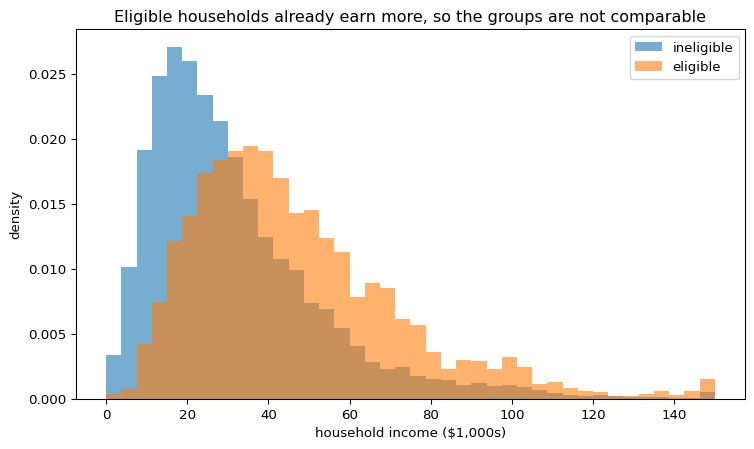

In [3]:
plt.figure(figsize=(9, 5))
plt.hist(savings.loc[savings.e401 == 0, "inc"].clip(0, 150), bins=40,
         alpha=0.6, density=True, label="ineligible")
plt.hist(savings.loc[savings.e401 == 1, "inc"].clip(0, 150), bins=40,
         alpha=0.6, density=True, label="eligible")
plt.xlabel("household income ($1,000s)")
plt.ylabel("density")
plt.title("Eligible households already earn more, so the groups are not comparable")
plt.legend()
plt.show()

The eligible group sits to the right of the ineligible group, its income
distribution is shifted rightwards. Some of the \$19,600 gap is the
effect of eligibility, and some of it comes from comparing richer
households with poorer ones. The naive difference mixes the two together
and can’t separate them. This leads to bias.

The household’s characteristics $X$, its income, age, and the rest,
influence both whether it is eligible and how much it saves. A variable
that causes both the treatment and the outcome is a **confounder**, and
it is what makes the naive comparison untrustworthy.

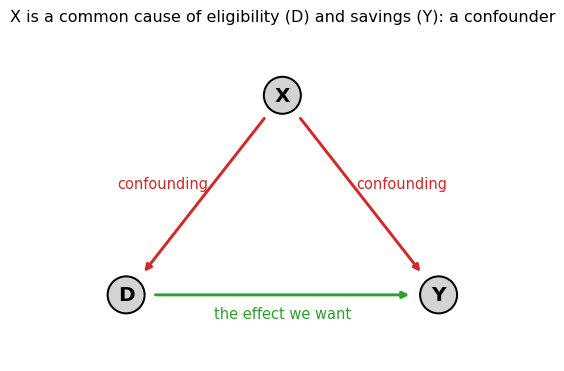

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
nodes = {"X": (0.5, 0.8), "D": (0.2, 0.2), "Y": (0.8, 0.2)}
box = dict(boxstyle="circle,pad=0.45", fc="lightgrey", ec="black", lw=1.5)
for name, (x, y) in nodes.items():
    ax.text(x, y, name, ha="center", va="center", fontsize=15, fontweight="bold", bbox=box, zorder=3)

def draw_arrow(start, end, color):
    ax.annotate("", xy=nodes[end], xytext=nodes[start],
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, shrinkA=22, shrinkB=22))

draw_arrow("X", "D", "tab:red")
draw_arrow("X", "Y", "tab:red")
draw_arrow("D", "Y", "tab:green")
ax.text(0.27, 0.52, "confounding", color="tab:red", ha="center", fontsize=11)
ax.text(0.73, 0.52, "confounding", color="tab:red", ha="center", fontsize=11)
ax.text(0.5, 0.13, "the effect we want", color="tab:green", ha="center", fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("X is a common cause of eligibility (D) and savings (Y): a confounder")
plt.show()

The arrow from $D$ to $Y$ is the effect we are after (401(k) eligibility
on savings). The two red arrows out of $X$ are the problem: they open a
second route by which eligible and ineligible households come to differ
in savings, one that is unrelated nothing to the $D \to Y$ arrow. To
recover the effect we have to deal with $X$ somehow, and to say
precisely what we mean by “the effect” we first need a small piece of
vocabulary.

## 2. Potential outcomes

Think about a single household and two versions of the world. In one it
is eligible for a 401(k); in the other it is not. Note that apart from
the 401(k) eligibility nothing else has changed, we hold everything else
fixed, the households are otherwise identical. Write $Y(1)$ for the
savings it would end up with if eligible, and $Y(0)$ for the savings it
would end up with if not. These are its two **potential outcomes**. The
effect of eligibility on that household is the difference between them:

$$
\text{effect for household } i = Y_i(1) - Y_i(0).
$$

If we could see both numbers for every household, causal inference would
just be subtraction. To demonstrate this we will make a made up world
where we can see $Y(1)$ and $Y(0)$ for 5 households.

In [5]:
world = pd.DataFrame({
    "household": [1, 2, 3, 4, 5],
    "Y0_if_ineligible": [12, 3, 30, 1, 45],
    "Y1_if_eligible":   [16, 9, 33, 8, 47],
})
world["effect"] = world["Y1_if_eligible"] - world["Y0_if_ineligible"]
world["eligible_D"] = [1, 0, 1, 0, 1]
world

The `effect` column is what we are after. But now look at what we
actually get to observe in the real world. Each household lives in only
one version of the world: if it is eligible we see $Y(1)$ and never
$Y(0)$, and if it is not we see $Y(0)$ and never $Y(1)$. Another
possible example is a medical trial for a new drug, the patient either
takes the drug or the placebo, we cannot have two identical people take
one of each, it’s either one or the other. The other potential outcome
is a counterfactual we can never measure.

Here is a table from our real world.

In [6]:
observed = world.copy()
observed["Y0_if_ineligible"] = np.where(world.eligible_D == 0, world.Y0_if_ineligible, np.nan)
observed["Y1_if_eligible"] = np.where(world.eligible_D == 1, world.Y1_if_eligible, np.nan)
observed = observed.drop(columns=["effect"])  # unknowable, one outcome per row is missing
observed

Half of each row is gone, and with it the `effect` column. This is the
**fundamental problem of causal inference**: for any one household we
see at most one of its two potential outcomes, so its individual effect
is never observed and we can’t directly measure it for any single
household.

What we can still hope for, though, is an average.

The **average treatment effect (ATE)** is the average of the individual
effects across all households:

$$
\text{ATE} = \mathbb{E}\big[\, Y(1) - Y(0) \,\big].
$$

ATE calculates how much eligibility would change savings on average if
it were applied to everyone. The rest of the notebook is about
calculating it from our real world table (which is missing half its
entries).

### 2.1 Selection bias

The naive difference from section 1.1 compares the savings we observe
for the eligible with the savings we observe for the ineligible:

$$
\mathbb{E}[Y \mid D = 1] - \mathbb{E}[Y \mid D = 0].
$$

Write this in potential-outcome terms. Among the eligible we observe
$Y(1)$, and among the ineligible we observe $Y(0)$, so the naive
difference is
$\mathbb{E}[Y(1) \mid D = 1] - \mathbb{E}[Y(0) \mid D = 0]$. Add and
subtract the savings the eligible group would have had without
eligibility, $\mathbb{E}[Y(0) \mid D = 1]$, and it splits into two
pieces:

$$
\underbrace{\mathbb{E}[Y(1) \mid D=1] - \mathbb{E}[Y(0) \mid D=1]}_{\text{effect on the eligible}} \;+\; \underbrace{\mathbb{E}[Y(0) \mid D=1] - \mathbb{E}[Y(0) \mid D=0]}_{\text{selection bias}}.
$$

The first piece is a real treatment effect. The second is **selection
bias**: the gap in $Y(0)$, the savings the two groups would have had
even with no 401(k) anywhere. If eligible households are richer and save
more to begin with, that gap is positive and the naive difference
overstates the effect.

We cannot see the size of the bias in the real 401(k) data, because
$Y(0)$ for the eligible is one of our missing counterfactuals. So we
build a world where we set the true effect ourselves and can watch the
bias appear. Each household has covariates $X$; both its eligibility and
its savings depend on $X$, which is what ties them together and creates
the bias (remember our causal diagram with $D$, $X$, $Y$).

Because we built this world, we can do something the 401(k) data never
allows: look at $Y(0)$, the savings under no 401(k), for every
household, including the eligible ones whose $Y(0)$ is a counterfactual
in real life. The function below returns both potential outcomes next to
what we would actually observe.

In [7]:
def simulate(n, p, confounding, seed):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, p))
    j = np.arange(1, p + 1)
    beta = 4.0 / j**2                      # a few covariates drive savings, the rest are noise
    gamma = confounding / j**2             # the same covariates push eligibility: the confounding
    propensity = 1 / (1 + np.exp(-(X @ gamma)))
    D = (rng.uniform(size=n) < propensity).astype(float)
    noise = rng.normal(0, 1, n)
    Y0 = X @ beta + noise                  # savings with no 401(k)
    Y1 = TRUE_EFFECT + X @ beta + noise    # savings with a 401(k)
    Y = np.where(D == 1, Y1, Y0)           # in real life we would see only one of these per row
    return X, D, Y, Y0, Y1, propensity

X_low, D_low, Y_low, Y0_low, Y1_low, propensity_low = simulate(
    n=4000, p=20, confounding=2.0, seed=RANDOM_STATE)
naive_low = Y_low[D_low == 1].mean() - Y_low[D_low == 0].mean()

The decomposition above asked for two quantities we normally cannot
compute. The effect on the eligible is the average of $Y(1) - Y(0)$
among them, and the selection bias is the gap in $Y(0)$ between the two
groups.

In [8]:
effect_on_eligible = (Y1_low - Y0_low)[D_low == 1].mean()
selection_bias = Y0_low[D_low == 1].mean() - Y0_low[D_low == 0].mean()
print(f"Naive difference        : {naive_low:.2f}")
print(f"  effect on the eligible: {effect_on_eligible:.2f}")
print(f"  selection bias        : {selection_bias:.2f}")
print(f"True effect we built in : {TRUE_EFFECT:.2f}")

Naive difference        : 6.14
  effect on the eligible: 1.00
  selection bias        : 5.14
True effect we built in : 1.00

The naive difference of 6.14 is the true effect of 1 plus a selection
bias of 5.14. The bias is five times the size of the quantity we are
trying to measure. We can see exactly where it comes from by plotting
$Y(0)$, the savings each household would have had with no 401(k), for
the two groups side by side.

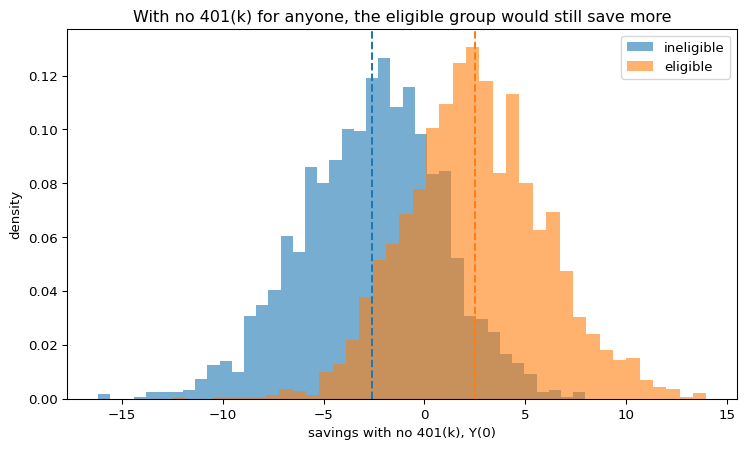

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(Y0_low[D_low == 0], bins=40, alpha=0.6, density=True, label="ineligible")
plt.hist(Y0_low[D_low == 1], bins=40, alpha=0.6, density=True, label="eligible")
plt.axvline(Y0_low[D_low == 0].mean(), color="tab:blue", linestyle="--")
plt.axvline(Y0_low[D_low == 1].mean(), color="tab:orange", linestyle="--")
plt.xlabel("savings with no 401(k), Y(0)")
plt.ylabel("density")
plt.title("With no 401(k) for anyone, the eligible group would still save more")
plt.legend()
plt.show()

Both curves are drawn in a world where no household has a 401(k), so
neither is affected by the treatment. They still do not line up: the
eligible households, the orange histogram, sit to the right and would
have saved more regardless, because the same covariates that make them
likely to be eligible also make them savers (better job, higher
propensity to save, age, etc). That gap, with the treatment removed
entirely, is the selection bias. The naive comparison cannot separate it
from the effect so it includes it.

### 2.2 Unconfoundedness

This is the most key assumption in this whole stream, so we will explore
it in detail. The reason the naive comparison fails is that eligibility
was decided in a way that depends on $X$, and $X$ also drives savings.
Suppose instead we could find, for every eligible household, an
ineligible household identical on $X$: same income, age, education,
family size, everything we measured. Within such a pair, the only
systematic difference left is eligibility, so comparing them recovers an
effect. This is **unconfoundedness** (also called selection on
observables or conditional independence):

$$
\big(Y(0), Y(1)\big) \;\perp\; D \;\mid\; X.
$$

The $\;\perp\;$ symbol means independent.

In words: once we hold $X$ fixed, which household is eligible is as good
as random. For our data it says that among households that match on
everything we measured, whether one of them has a job that offers a
401(k) tells us nothing more about how much it would have saved on its
own. It would fail if households differ in some way the survey never
recorded, for example a propensity for saving, that both steers them
into eligible jobs and pushes up their savings. Then eligible and
ineligible households still differ after we condition on $X$, and no
adjustment on $X$ can repair it.

There is a companion requirement called **overlap** or **positivity**:
at every value of $X$ there must be both eligible and ineligible
households, or there is no comparison to make. Together they let us
write the ATE as an average of within-$X$ comparisons:

$$
\text{ATE} = \mathbb{E}_X\Big[\, \mathbb{E}[Y \mid D=1, X] - \mathbb{E}[Y \mid D=0, X] \,\Big].
$$

> **Unconfoundedness is an assumption, not a result**
>
> Nothing in the data can confirm $(Y(0), Y(1)) \perp D \mid X$, because
> it involves the potential outcomes we never observe. We assume that
> the covariates we collected capture every systematic reason a
> household ends up eligible, we adjust for $X$ on that basis, and we
> know that the whole estimate rests on the assumption.

In our simulated world unconfoundedness holds by construction, because
we built $D$ to depend only on the $X$ we recorded, so we can watch the
assumption do its work. We sort the households into ten groups by how
likely they were to be eligible, a single number that summarises $X$,
and inside each group we compare the savings of the eligible with the
ineligible. Within a narrow group the two sides are alike, so the
comparison should be close to the true effect.

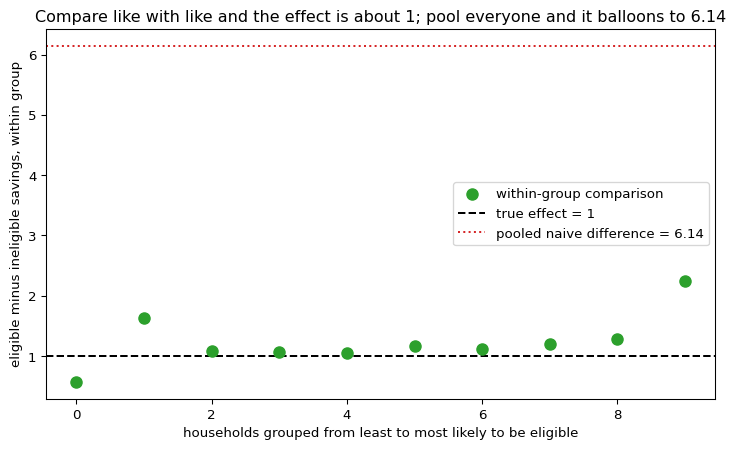

In [10]:
strata = pd.qcut(propensity_low, 10, labels=False, duplicates="drop")
within_stratum = [Y_low[(strata == s) & (D_low == 1)].mean()
                  - Y_low[(strata == s) & (D_low == 0)].mean()
                  for s in sorted(set(strata))]

plt.figure(figsize=(9, 5))
plt.scatter(range(len(within_stratum)), within_stratum, s=70, color="tab:green",
            zorder=3, label="within-group comparison")
plt.axhline(TRUE_EFFECT, color="black", linestyle="--", label=f"true effect = {TRUE_EFFECT:.0f}")
plt.axhline(naive_low, color="tab:red", linestyle=":", label=f"pooled naive difference = {naive_low:.2f}")
plt.xlabel("households grouped from least to most likely to be eligible")
plt.ylabel("eligible minus ineligible savings, within group")
plt.title("Compare like with like and the effect is about 1; pool everyone and it balloons to 6.14")
plt.legend()
plt.show()

In the middle groups the within-group comparison sits close to the true
effect of 1, far below the pooled naive difference of 6.14. This is the
unconfoundedness assumption working: once we compare households that
look alike, the selection bias is gone and what is left is the true
effect. The end groups wander upwards, and that is the **overlap**
problem showing up. In the lowest group almost no one is eligible and in
the highest almost everyone is, so there are too few of the other side
to compare against, and the estimate gets noisy. Comparing within groups
like this is one way to adjust for $X$. The compact version of this is
to put $D$ and $X$ into one linear regression and read the coefficient
on $D$.

In [11]:
ols_adjust = LinearRegression().fit(np.column_stack([D_low, X_low]), Y_low).coef_[0]
print(f"True effect      : {TRUE_EFFECT:.2f}")
print(f"Naive difference : {naive_low:.2f}")
print(f"Adjusted for X   : {ols_adjust:.2f}")

True effect      : 1.00
Naive difference : 6.14
Adjusted for X   : 1.04

Adjusting for $X$ brings the estimate from 6.14 back to 1.04, recovering
the effect of 1 we built in. The same adjustment changes the 401(k)
number too.

In [12]:
adjusted_401k = LinearRegression().fit(
    np.column_stack([D, savings[confounders].to_numpy()]), Y).coef_[0]
print(f"401(k) naive gap      : {naive_gap:.1f}")
print(f"401(k) adjusted for X : {adjusted_401k:.1f}")

401(k) naive gap      : 19.6
401(k) adjusted for X : 5.9

Adjusting cuts the 401(k) gap from about 19,600 to about 5,900 dollars.
We cannot check that number against a known truth the way we can in the
simulation, and it still rests on unconfoundedness, but it is the
comparison we want: eligible against ineligible households that look
alike on what we measured.

## 3 The role of machine learning

Look again at the identification formula. To estimate the ATE under
unconfoundedness we need $\mathbb{E}[Y \mid D, X]$, the expected savings
given treatment and covariates. That is a function of $X$, and learning
a function of $X$ from data is the prediction problems from Notebooks 1
to 3. A closely related quantity, the **propensity score**
$\mathbb{E}[D \mid X]$, the probability of being eligible given the
covariates, is another prediction problem based around classification.
We have learned tools to solve both of these!

This is how machine learning is used in causal inference. The treatment
effect is the target, and the regressions of $Y$ on $X$ and of $D$ on
$X$ are **nuisance** functions: functions we have to estimate correctly
so the effect comes out right, but that are not themselves the answer.
In section 2 the nuisance was simple enough for OLS. When there are many
covariates or the relationships are nonlinear, OLS is the wrong tool,
for the reasons Notebook 2 laid out, and instead we utilize lasso, a
forest, or boosting.

It would seem we’re done: estimate $\mathbb{E}[Y \mid D, X]$ with the
best predictor we have and read off the effect. But that doesn’t work,
so let’s find out why.

### 3.1 The catch: machine learning used naively gives a biased effect

We move to a world with many covariates and stronger confounding, the
setting where a flexible learner is the only option and where issues
start to arise. Here there are 150 covariates and 300 households, the
high-dimensional situation from Notebook 2, so OLS breaks and we use
lasso for the adjustment.

The naive way to use it mirrors section 2.2: put $D$ and all of $X$ into
one lasso and read the coefficient on $D$.

In [13]:
X_high, D_high, Y_high, *_ = simulate(n=300, p=150, confounding=4.0, seed=RANDOM_STATE)

naive_high = Y_high[D_high == 1].mean() - Y_high[D_high == 0].mean()

design = np.column_stack([D_high, X_high])
naive_lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000).fit(design, Y_high).coef_[0]

print(f"True effect        : {TRUE_EFFECT:.2f}")
print(f"Naive difference   : {naive_high:.2f}")
print(f"Naive single lasso : {naive_lasso:.2f}")

True effect        : 1.00
Naive difference   : 6.88
Naive single lasso : 0.75

The naive difference is a terrible estimator at 6.88. The single lasso
is closer, but 0.75 is well below our true effect of 1. The lasso
penalty shrinks every coefficient toward zero to control variance, and
it shrinks the coefficient on $D$ along with the rest, even though that
is the one coefficient we don’t want shrunk (it is the target). This is
**regularization bias**, the warning Notebook 2 ended on: a
lasso-selected coefficient is not a clean effect.

The fix is to stop asking a single penalized regression to find the
effect. Instead we use machine learning only for the nuisance functions
($Y$ on $X$ and $D$ on $X$) and keep the effect itself out of the
penalty. This is **orthogonalization**, the same idea as adjusting for
$X$ in section 2.2, now done on each side individually. We partial $X$
out of the outcome and out of the treatment, each with its own lasso,
and then relate what is left over:

1.  Predict $Y$ from $X$ and take the residual
    $\tilde{Y} = Y - \hat{\mathbb{E}}[Y \mid X]$: the part of savings
    the covariates do not explain.
2.  Predict $D$ from $X$ and take the residual
    $\tilde{D} = D - \hat{\mathbb{E}}[D \mid X]$: the part of
    eligibility the covariates do not explain.
3.  Regress $\tilde{Y}$ on $\tilde{D}$. That slope is the effect.

The final step is an ordinary unpenalized regression of one residual on
the other, so the penalty never touches the effect.

In [14]:
y_resid = Y_high - LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000).fit(X_high, Y_high).predict(X_high)
d_resid = D_high - LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=50000).fit(X_high, D_high).predict(X_high)
orthogonal = (d_resid @ y_resid) / (d_resid @ d_resid)

print(f"True effect        : {TRUE_EFFECT:.2f}")
print(f"Naive single lasso : {naive_lasso:.2f}")
print(f"Orthogonalized     : {orthogonal:.2f}")

True effect        : 1.00
Naive single lasso : 0.75
Orthogonalized     : 1.07

We can look at that final regression directly. Each point below is one
household, placed by how much of its eligibility and its savings are
left unexplained by $X$. The slope of the line through them is the
effect.

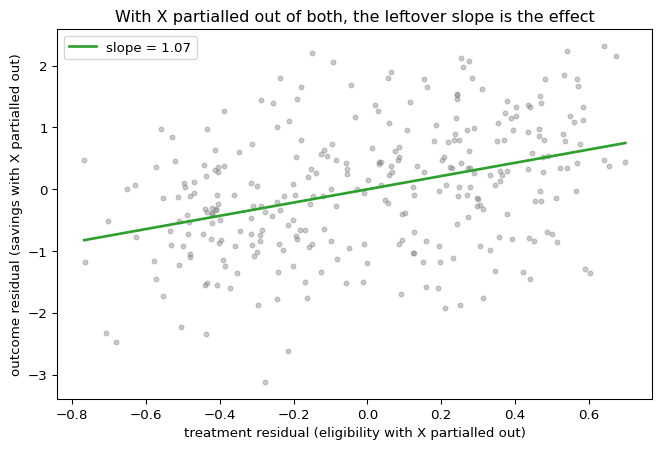

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(d_resid, y_resid, s=12, alpha=0.4, color="grey")
grid = np.array([d_resid.min(), d_resid.max()])
plt.plot(grid, orthogonal * grid, color="tab:green", linewidth=2,
         label=f"slope = {orthogonal:.2f}")
plt.xlabel("treatment residual (eligibility with X partialled out)")
plt.ylabel("outcome residual (savings with X partialled out)")
plt.title("With X partialled out of both, the leftover slope is the effect")
plt.legend()
plt.show()

Once $X$ is removed from both eligibility and savings, the part left
over lines up along a slope of 1.07, which is very close to the effect
of 1 we constructed. Let’s compare all three estimates we used.

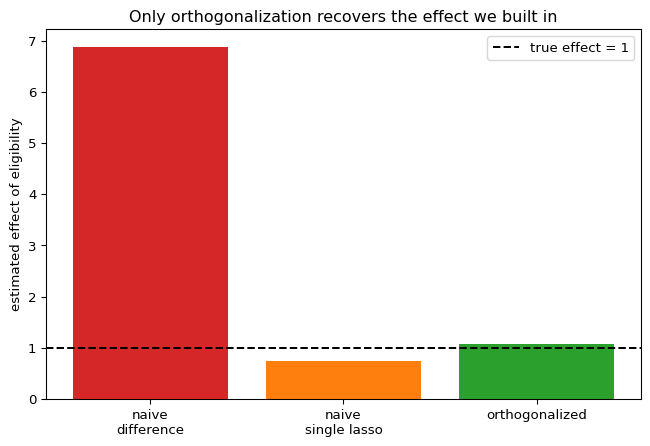

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(["naive\ndifference", "naive\nsingle lasso", "orthogonalized"],
        [naive_high, naive_lasso, orthogonal],
        color=["tab:red", "tab:orange", "tab:green"])
plt.axhline(TRUE_EFFECT, color="black", linestyle="--", label=f"true effect = {TRUE_EFFECT:.0f}")
plt.ylabel("estimated effect of eligibility")
plt.title("Only orthogonalization recovers the effect we built in")
plt.legend()
plt.show()

We can still improve upon this! There is a second, subtler bias we have
not removed: we fit the nuisance lassos and computed the effect on the
same households, so the residuals carry a little of the lassos’ own
overfitting. The way we fix this is using **cross-fitting**: split the
data, fit the nuisances on one part, take residuals on the other, and
rotate, this is similar to cross-validation in Notebook 1.
Orthogonalization plus cross-fitting is **double machine learning**, the
subject of Notebook 7, where we build the estimator in full and attach
standard errors to it.

> **Self-test**
>
> We adjusted for $X$ with OLS in section 2.2 and it worked. Why not
> just always use OLS and avoid the regularization bias entirely?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> Because OLS only works when the covariates are few relative to the
> sample, like section 2.2. With many covariates, our setting in section
> 3.1 and in Notebook 2, OLS overfits and falls apart, so we have to use
> a regularized or flexible learner for the nuisance. Regularization is
> necessary, and orthogonalization is what removes the bias.
>
> </details>

### 3.2 When unconfoundedness fails

Everything above rests on unconfoundedness: the covariates we adjusted
for capture every systematic reason a household is eligible. But let’s
suppose they do not. Suppose the most important confounder is something
we never measured. We can see what that does by taking our
low-dimensional world and adjusting for every covariate except the most
important one, as if it had been left out of the survey.

In [17]:
ols_hidden = LinearRegression().fit(np.column_stack([D_low, X_low[:, 1:]]), Y_low).coef_[0]
print(f"True effect             : {TRUE_EFFECT:.2f}")
print(f"Adjusted for all X      : {ols_adjust:.2f}")
print(f"Adjusted, top X hidden  : {ols_hidden:.2f}")

True effect             : 1.00
Adjusted for all X      : 1.04
Adjusted, top X hidden  : 5.87

With the strongest confounder hidden, the adjusted estimate jumps from 1
to 5.87, almost as biased as the naive difference. No amount of
technique with the covariates we do have can fix a confounder we don’t
have. Orthogonalization, cross-fitting, a stronger learner, none of them
helps here, because what we are missing is information rather than a
better method.

This is where the tools you met in COMET come back. When
unconfoundedness is too much to assume, we look for a different source
of variation. **Instrumental variables** uses a variable that shifts the
treatment but affects the outcome only through it.
**Difference-in-differences** uses the timing of a treatment together
with a parallel-trends assumption. These are different identification
strategies, each resting on its own assumption rather than on adjusting
for $X$, and machine learning extends them too. Picking between
adjusting for $X$, an instrument, or a difference-in-differences design
really comes down to which assumption you are willing to defend.

> **Its causal future**
>
> From here the stream builds out the toolkit this notebook set up.
> Notebook 5 fixes the regularization bias for lasso specifically, with
> post-double-selection. Notebook 6 estimates the propensity score
> $\mathbb{E}[D \mid X]$ and uses it to reweight. Notebook 7 builds
> double machine learning, the orthogonalization and cross-fitting of
> section 3.1, in full. Notebook 8 moves from the average effect to who
> benefits most, with causal forests. Each one is a prediction tool from
> Notebooks 1 to 3, but now in its proper causal clothing.

## Connections

-   **Back to [Notebook 3](notebook_03_trees_forests_boosting.qmd):**
    Notebook 3 finished the prediction toolkit with trees, forests and
    boosting.
-   **Forward to [Notebook 5](notebook_05_post_double_selection.qmd):**
    post-double-selection lasso, the proper fix for the regularization
    bias of section 3.1, on the growth and convergence question from
    Notebook 2.

### References

-   Belloni, A., Chernozhukov, V., & Hansen, C. (2014).
    *High-dimensional methods and inference on structural and treatment
    effects.* Journal of Economic Perspectives, 28(2), 29-50.
    Regularization bias and the double-selection fix.
-   CausalWizard. (n.d.). *Average treatment effect (ATE).*
    CausalWizard. https://causalwizard.app/inference/article/ate
-   Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen,
    C., Newey, W., & Robins, J. (2018). *Double/debiased machine
    learning for treatment and structural parameters.* Econometrics
    Journal, 21(1), C1-C68. Orthogonalization and cross-fitting.
-   Didelez, V., & Evans, R. J. (2025). *Causal assumptions.* In *Causal
    Inference* (APTS lecture notes), University of Oxford.
    https://www.stats.ox.ac.uk/~evans/APTS/causassmp.html
-   GeeksforGeeks. (2026). *Causal machine learning.* GeeksforGeeks.
    https://www.geeksforgeeks.org/machine-learning/causal-machine-learning/
-   Imbens, G. W., & Rubin, D. B. (2015). *Causal Inference for
    Statistics, Social, and Biomedical Sciences.* Cambridge University
    Press. The potential-outcomes framework.
-   Poterba, J. M., Venti, S. F., & Wise, D. A. (1995). *Do 401(k)
    contributions crowd out other personal saving?* Journal of Public
    Economics, 58(1), 1-32. The eligibility question.
-   Wikipedia contributors. (2026). *Ignorability.* Wikipedia.
    https://en.wikipedia.org/wiki/Ignorability

------------------------------------------------------------------------